In [123]:
from datetime import datetime
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import glob
import matplotlib.image as mpimg
import pandas as pd

# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)


# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)

# Custom imports
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement

import importlib
import pinns_solution_functions

importlib.reload(pinns_solution_functions)
from pinns_solution_functions import (
    set_seed, generate_points, MLP, init_weights,
    train_adam_with_logs_adaptive, train_lbfgs_with_logs_adaptive,
    predict_displacement_pinns, mse_f_adaptive, mse_b_adaptive,
    split_adaptive_points, to_training_format,prepare_points_and_residuals,
    compute_rad_probability,plot_sampling_points
)

# Seed
set_seed(42)

output_dir = "figs_sampling"
os.makedirs(output_dir, exist_ok=True)

In [124]:
def plot_sampling_with_residual(X, res, title="Sampling"):
    
   
    plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        X[:, 0], X[:, 1],
        c=res,
        s=15,
        alpha=1.0,
        cmap="Blues",
        edgecolors='none'
    )

    plt.colorbar(sc, label="Residual (ln)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)

    plt.gca().set_aspect('equal')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [148]:
r_i = np.pi / 4
l_e = np.pi
side_length = 2 * l_e
n_grid = 501
k = 3.0

# Base sampling
n_Omega_P = 10_000
n_Gamma_I = 100
n_Gamma_E = 250

# For adaptative
n_Omega_P_adaptive = 10_000 * 10
n_Gamma_I_adaptive = 100 * 10
n_Gamma_E_adaptive = 250 * 10

# Training
adam_lr = 1e-2
adam_iters = 1_00
lbfgs_iters = 5_00

hidden_layers_ = 3
hidden_units_  = 25

# Grid
Y, X = np.mgrid[-l_e:l_e:n_grid*1j, -l_e:l_e:n_grid*1j]
R_exact = np.sqrt(X**2 + Y**2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Activation
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

activation_function_ = Sine()

In [147]:
x_f, y_f, x_inner, y_inner, x_left, y_left, x_right, y_right, \
x_bottom, y_bottom, x_top, y_top = generate_points(
    n_Omega_P, side_length, r_i, n_Gamma_I, n_Gamma_E
)

In [135]:
x_f

tensor([-2.7702,  2.8653, -0.0054,  ..., -1.5942,  0.8930, -1.6415],
       device='cuda:0', requires_grad=True)

In [132]:
u_inc_exact, u_scn_exact, u_exact = sound_hard_circle_calc(k, r_i, X, Y, n_terms=None)
u_inc_exact = mask_displacement(R_exact, r_i, l_e, u_inc_exact)
u_scn_exact = mask_displacement(R_exact, r_i, l_e, u_scn_exact)
u_exact = mask_displacement(R_exact, r_i, l_e, u_exact)


===== RAD Iteration 1/10 =====

===== RAD Iteration 2/10 =====


IndexError: list index out of range

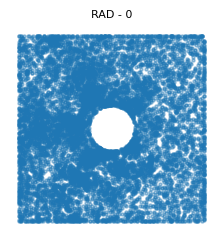

In [149]:
model = MLP(
    input_size=2,
    output_size=2,
    hidden_layers=hidden_layers_,
    hidden_units=hidden_units_,
    activation_function=activation_function_
).to(device)

model.apply(init_weights)

# ================= RAD LOOP =================
n_RAD_iters = 10

results = []
iter_train = 0

for it in range(n_RAD_iters):


    print(f"\n===== RAD Iteration {it+1}/{n_RAD_iters} =====")

    # -------- ADAM --------
    iter_train = train_adam_with_logs_adaptive(
        model,
        x_f, y_f,
        x_inner, y_inner,
        x_left, y_left,
        x_right, y_right,
        x_bottom, y_bottom,
        x_top, y_top,
        k,
        iter_train,
        results,
        adam_lr,
        num_iter=adam_iters,
        save_csv_path=None,
        save_csv_path_no_datetime=None,
        l_e=l_e,
        r_i=r_i,
        n_grid=n_grid,
        X=X,
        Y=Y,
        R_exact=R_exact,
        u_scn_exact=u_scn_exact,
        u_exact=u_exact
    )

    # -------- L-BFGS --------
    iter_train, res_f, res_inner, res_left, res_right, res_bottom, res_top = train_lbfgs_with_logs_adaptive(
        model,
        x_f, y_f,
        x_inner, y_inner,
        x_left, y_left,
        x_right, y_right,
        x_bottom, y_bottom,
        x_top, y_top,
        k,
        iter_start=iter_train,
        results=results,
        lbfgs_lr=1.0,
        num_iter=lbfgs_iters,
        save_csv_path=None,
        save_csv_path_no_datetime=f'data/{it+1}_adaptive_sampling.csv',
        l_e=l_e,
        r_i=r_i,
        n_grid=n_grid,
        X=X,
        Y=Y,
        R_exact=R_exact,
        u_scn_exact=u_scn_exact,
        u_exact=u_exact
    )

    x_f_adaptive, y_f_adaptive, x_inner_adaptive, y_inner_adaptive, x_left_adaptive, y_left_adaptive, x_right_adaptive, y_right_adaptive, \
    x_bottom_adaptive, y_bottom_adaptive, x_top_adaptive, y_top_adaptive = generate_points(
        n_Omega_P_adaptive, side_length, r_i, n_Gamma_I_adaptive, n_Gamma_E_adaptive
    )

    _, res_f = mse_f_adaptive(model, x_f_adaptive, y_f_adaptive, k)

    # Boundary residuals
    _, res_inner, res_left, res_right, res_bottom, res_top = mse_b_adaptive(
        model,
        x_inner_adaptive, y_inner_adaptive,
        x_left_adaptive, y_left_adaptive,
        x_right_adaptive, y_right_adaptive,
        x_bottom_adaptive, y_bottom_adaptive,
        x_top_adaptive, y_top_adaptive,
        k
    )

    X_all_new, res_all_new = prepare_points_and_residuals(
        x_f_adaptive, y_f_adaptive, res_f,    
        x_inner_adaptive, y_inner_adaptive, res_inner,
        x_left_adaptive, y_left_adaptive, res_left,
        x_right_adaptive, y_right_adaptive, res_right,
        x_bottom_adaptive, y_bottom_adaptive, res_bottom,
        x_top_adaptive, y_top_adaptive, res_top
    )

    prob = compute_rad_probability(res_all_new, k=1.0, c=1.0)

    N_total = 10_350

    # Sample WITHOUT replacement
    prob = torch.tensor(prob, dtype=torch.float32)
    ids = torch.multinomial(prob, N_total, replacement=False)

    # Select new points
    X_selected = X_all_new[ids]

    # Split
    X_f_new, X_inner_new, X_left_new, X_right_new, X_bottom_new, X_top_new = split_adaptive_points(
        X_selected,
        n_Omega_P_adaptive,
        n_Gamma_I_adaptive,
        n_Gamma_E_adaptive
    )

    # Convert back to tensors
    device = x_f_adaptive.device

    x_f_adaptive, y_f_adaptive, \
    x_inner_adaptive, y_inner_adaptive, \
    x_left_adaptive, y_left_adaptive, \
    x_right_adaptive, y_right_adaptive, \
    x_bottom_adaptive, y_bottom_adaptive, \
    x_top_adaptive, y_top_adaptive = to_training_format(
        X_f_new, X_inner_new,
        X_left_new, X_right_new,
        X_bottom_new, X_top_new,
        device
    )

    plot_sampling_points(
        x_f_adaptive, y_f_adaptive,
        x_inner_adaptive, y_inner_adaptive,
        x_left_adaptive, y_left_adaptive,
        x_right_adaptive, y_right_adaptive,
        x_bottom_adaptive, y_bottom_adaptive,
        x_top_adaptive, y_top_adaptive,
        it
    )

    x_f = x_f_adaptive
    y_f = y_f_adaptive
    x_inner = x_inner_adaptive
    y_inner = y_inner_adaptive
    x_left = x_left_adaptive
    y_left = y_left_adaptive
    x_right = x_right_adaptive
    y_right = y_right_adaptive
    x_bottom = x_bottom_adaptive
    y_bottom = y_bottom_adaptive
    x_top = x_top_adaptive  
    y_top = y_top_adaptive  




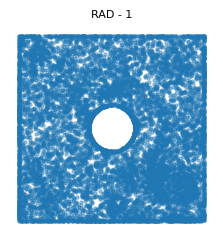

In [152]:
x_f_adaptive, y_f_adaptive, x_inner_adaptive, y_inner_adaptive, x_left_adaptive, y_left_adaptive, x_right_adaptive, y_right_adaptive, \
x_bottom_adaptive, y_bottom_adaptive, x_top_adaptive, y_top_adaptive = generate_points(
    n_Omega_P_adaptive, side_length, r_i, n_Gamma_I_adaptive, n_Gamma_E_adaptive
)

_, res_f = mse_f_adaptive(model, x_f_adaptive, y_f_adaptive, k)

# Boundary residuals
_, res_inner, res_left, res_right, res_bottom, res_top = mse_b_adaptive(
    model,
    x_inner_adaptive, y_inner_adaptive,
    x_left_adaptive, y_left_adaptive,
    x_right_adaptive, y_right_adaptive,
    x_bottom_adaptive, y_bottom_adaptive,
    x_top_adaptive, y_top_adaptive,
    k
)

X_all_new, res_all_new = prepare_points_and_residuals(
    x_f_adaptive, y_f_adaptive, res_f,    
    x_inner_adaptive, y_inner_adaptive, res_inner,
    x_left_adaptive, y_left_adaptive, res_left,
    x_right_adaptive, y_right_adaptive, res_right,
    x_bottom_adaptive, y_bottom_adaptive, res_bottom,
    x_top_adaptive, y_top_adaptive, res_top
)

prob = compute_rad_probability(res_all_new, k=1.0, c=1.0)

N_total = 10_350

# Sample WITHOUT replacement
prob = torch.tensor(prob, dtype=torch.float32)
ids = torch.multinomial(prob, N_total, replacement=False)

# Select new points
X_selected = X_all_new[ids]

# Split
X_f_new, X_inner_new, X_left_new, X_right_new, X_bottom_new, X_top_new = split_adaptive_points(
    X_selected,
    n_Omega_P_adaptive,
    n_Gamma_I_adaptive,
    n_Gamma_E_adaptive
)

# Convert back to tensors
device = x_f_adaptive.device

x_f_adaptive, y_f_adaptive, \
x_inner_adaptive, y_inner_adaptive, \
x_left_adaptive, y_left_adaptive, \
x_right_adaptive, y_right_adaptive, \
x_bottom_adaptive, y_bottom_adaptive, \
x_top_adaptive, y_top_adaptive = to_training_format(
    X_f_new, X_inner_new,
    X_left_new, X_right_new,
    X_bottom_new, X_top_new,
    device
)

plot_sampling_points(
    x_f_adaptive, y_f_adaptive,
    x_inner_adaptive, y_inner_adaptive,
    x_left_adaptive, y_left_adaptive,
    x_right_adaptive, y_right_adaptive,
    x_bottom_adaptive, y_bottom_adaptive,
    x_top_adaptive, y_top_adaptive,
    it
)

x_f = x_f_adaptive
y_f = y_f_adaptive
x_inner = x_inner_adaptive
y_inner = y_inner_adaptive
x_left = x_left_adaptive
y_left = y_left_adaptive
x_right = x_right_adaptive
y_right = y_right_adaptive
x_bottom = x_bottom_adaptive
y_bottom = y_bottom_adaptive
x_top = x_top_adaptive  
y_top = y_top_adaptive  

In [145]:
x_inner_adaptive

tensor([], device='cuda:0', requires_grad=True)

In [87]:
results_control = pd.read_csv("data/training_log_3_layers_25_neurons.csv")  
results_adaptive = pd.read_csv("data/10_adaptive_sampling.csv")

/tmp/ipykernel_51277/3027095200.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


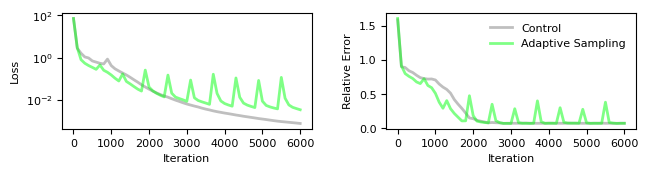

In [88]:
 
# Extract columns
it_c = results_control["iteration"]
loss_c = results_control["loss"]
err_c = results_control["mean_rel_error"]

it_a = results_adaptive["iteration"]
loss_a = results_adaptive["loss"]
err_a = results_adaptive["mean_rel_error"]

# ================= FIGURE =================
fig, axes = plt.subplots(1, 2, figsize=(7.4, 1.5),gridspec_kw={'wspace': 0.3})

# -------- LOSS (LEFT PANEL) --------
axes[0].plot(it_c, loss_c, color="gray", linewidth=2.0, alpha=0.5)
axes[0].plot(it_a, loss_a, color="#00ff0d", linewidth=2.0, alpha=0.5)

axes[0].set_xlabel("Iteration", fontsize=8)
axes[0].set_ylabel("Loss", fontsize=8)
axes[0].set_yscale("log")  # important
 
 
 
# -------- ERROR (RIGHT PANEL) --------
axes[1].plot(it_c, err_c, color="gray", linewidth=2.0, alpha=0.5)
axes[1].plot(it_a, err_a, color="#00ff0d", linewidth=2.0, alpha=0.5)

axes[1].set_xlabel("Iteration", fontsize=8)
axes[1].set_ylabel("Relative Error", fontsize=8)
 
# -------- Layout --------
for ax in axes:
    ax.tick_params(axis='both', labelsize=8) 

plt.legend(["Control", "Adaptive Sampling"], fontsize=8, loc="upper right", frameon=False) 
# -------- Layout --------
plt.tight_layout()
plt.savefig("figures/loss_error_adaptive_comparison.svg", dpi=300)
plt.show()